In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.formula.api import ols

### **Conjunto de dados**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/FIAP/Machine Learning & Data Science/Datasets/dataset_agrotech_regressao_linear.csv')

In [ ]:
df.sample(10)

,chuva_mm,temperatura_C,fertilizante_kg_ha,qualidade_solo,horas_sol_ano,uso_pesticidas_L_ha,produtividade_sacos_ha
1985,70.150378,18.062890,167.300274,2.924550,1568.630085,0.075411,187.221894
1886,52.332905,21.858593,81.507101,1.499355,2004.913920,9.727100,119.071680
1667,282.648804,31.777077,153.920180,3.207611,1427.362935,9.008370,265.194150
1956,210.641300,22.139649,150.402253,4.632134,1119.645138,1.627491,232.378705
804,156.032668,20.193417,114.987640,6.038948,2225.627420,4.349591,186.299368
1050,268.675418,33.688661,181.737870,8.289218,2391.457449,7.575838,303.186192
1705,76.416171,23.443845,54.658531,6.302906,1165.031864,0.762516,115.283829
2983,254.282036,15.891762,133.014155,1.964410,1561.396702,1.867684,225.879942
2228,124.309452,18.034858,138.399747,3.403548,1002.587233,5.255407,187.788030
2292,101.748145,15.787238,60.637429,5.984478,1325.869859,2.434953,118.963695


In [ ]:
df.describe()

,chuva_mm,temperatura_C,fertilizante_kg_ha,qualidade_solo,horas_sol_ano,uso_pesticidas_L_ha,produtividade_sacos_ha
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,174.973299,24.886299,123.108807,5.523215,1747.965990,5.041072,205.522992
std,72.914111,5.748474,42.837711,2.594266,435.668585,2.868277,43.531791
min,50.002909,15.000614,50.036151,1.000475,1001.805421,0.002525,87.950264
25%,111.451393,19.914551,86.220064,3.290721,1365.949178,2.592892,173.488703
50%,176.338436,24.760779,122.368750,5.491281,1736.656689,5.136897,203.726665
75%,238.583612,29.771807,159.301849,7.796397,2138.044527,7.469214,236.732134
max,299.929418,34.991154,199.919102,9.997059,2499.707716,9.999248,332.936349


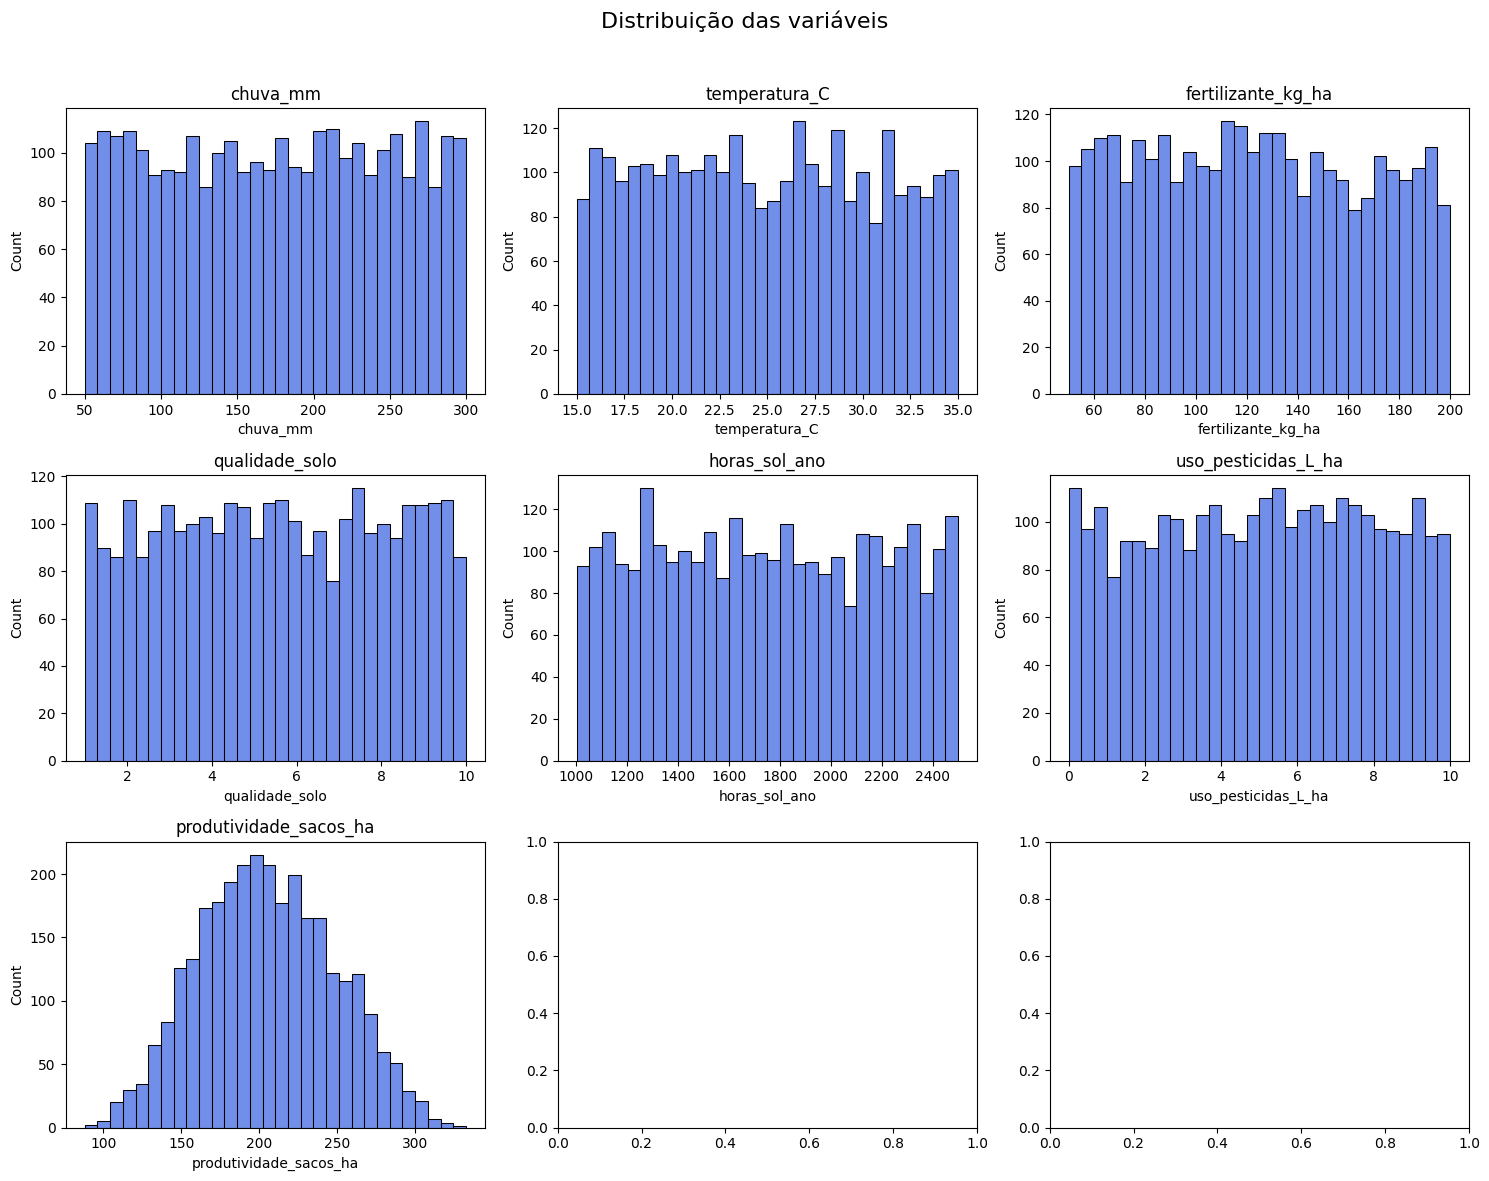

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribuição das variáveis', fontsize=16)

columns = df.columns
for i, ax in enumerate(axes.flat):
    if i <len(columns):
        sns.histplot(df[columns[i]], ax=ax, bins=30, color='royalblue')
        ax.set_title(columns[i], fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### **Correlação entre variáveis**

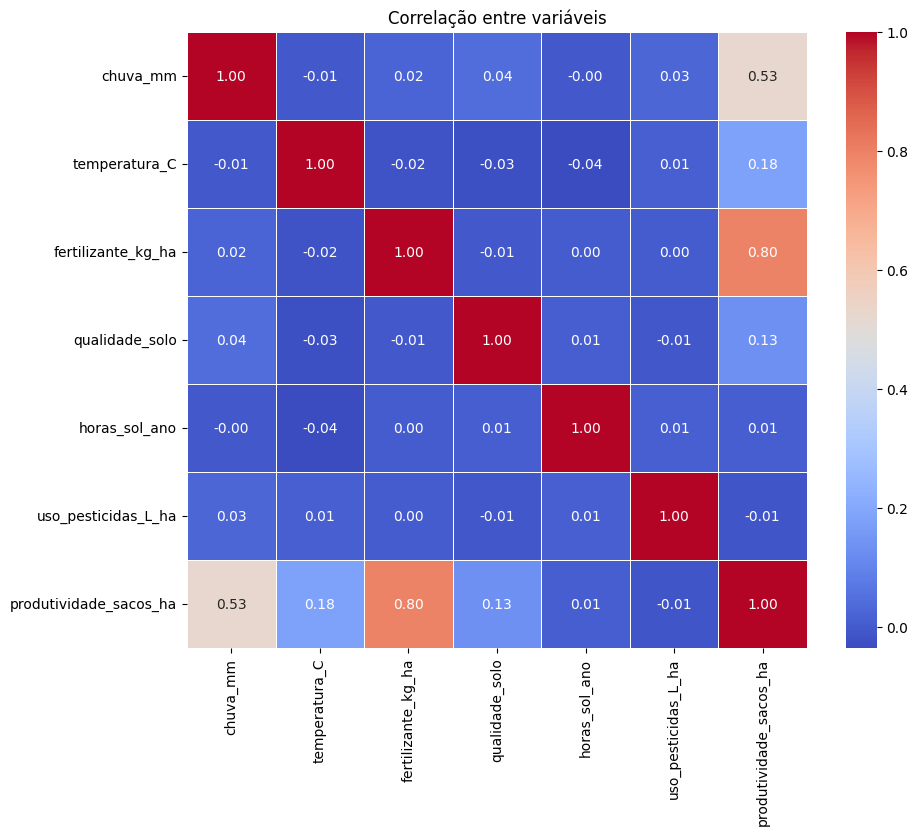

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlação entre variáveis')
plt.show()

### **Regressão Simples - Fertilizante x Produtividade**

In [ ]:
X = df['fertilizante_kg_ha']
y = df['produtividade_sacos_ha']

In [ ]:
model = sm.OLS(y, sm.add_constant(X)).fit()

In [ ]:
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     produtividade_sacos_ha   R-squared:                       0.636
Model:                                OLS   Adj. R-squared:                  0.636
Method:                     Least Squares   F-statistic:                     5242.
Date:                    Thu, 27 Mar 2025   Prob (F-statistic):               0.00
Time:                            23:31:00   Log-Likelihood:                -14060.
No. Observations:                    3000   AIC:                         2.812e+04
Df Residuals:                        2998   BIC:                         2.814e+04
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

#### **Regressão Simples - Pesticida X Produtividade**

In [ ]:
X = df['uso_pesticidas_L_ha']
y = df['produtividade_sacos_ha']

In [ ]:
model = sm.OLS(y, sm.add_constant(X)).fit()

In [ ]:
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     produtividade_sacos_ha   R-squared:                       0.000
Model:                                OLS   Adj. R-squared:                 -0.000
Method:                     Least Squares   F-statistic:                    0.6063
Date:                    Thu, 27 Mar 2025   Prob (F-statistic):              0.436
Time:                            23:34:14   Log-Likelihood:                -15576.
No. Observations:                    3000   AIC:                         3.116e+04
Df Residuals:                        2998   BIC:                         3.117e+04
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

#### **Regressão Multipla - Todas as variáveis**

In [ ]:
X = df.drop('produtividade_sacos_ha', axis=1)
y = df['produtividade_sacos_ha']

In [ ]:
model = sm.OLS(y, sm.add_constant(X)).fit()

In [ ]:
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     produtividade_sacos_ha   R-squared:                       0.947
Model:                                OLS   Adj. R-squared:                  0.947
Method:                     Least Squares   F-statistic:                     8935.
Date:                    Thu, 27 Mar 2025   Prob (F-statistic):               0.00
Time:                            23:36:55   Log-Likelihood:                -11167.
No. Observations:                    3000   AIC:                         2.235e+04
Df Residuals:                        2993   BIC:                         2.239e+04
Df Model:                               6                                         
Covariance Type:                nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

## **Regressão Linear com biblioteca Sklearn**

In [ ]:
X = df.drop('produtividade_sacos_ha', axis=1)
y = df['produtividade_sacos_ha']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# treinamento do modelo de regressão linear
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predição em dados de teste
y_pred = model.predict(X_test)

In [ ]:
# Avaliação do modelo
print("Coeficiente:", model.coef_)
print("Intercepto:", model.intercept_)
print("R²:", r2_score(y_test, y_pred))
print("Erro Quadrático Médio:", mean_squared_error(y_test, y_pred))

Coeficiente: [ 3.02002067e-01  1.52638007e+00  8.04388882e-01  1.99995916e+00
  1.63703202e-03 -4.02479697e-01]
Intercepto: 3.9575017392703558
R²: 0.945712159967853
Erro Quadrático Médio: 99.0805809709829


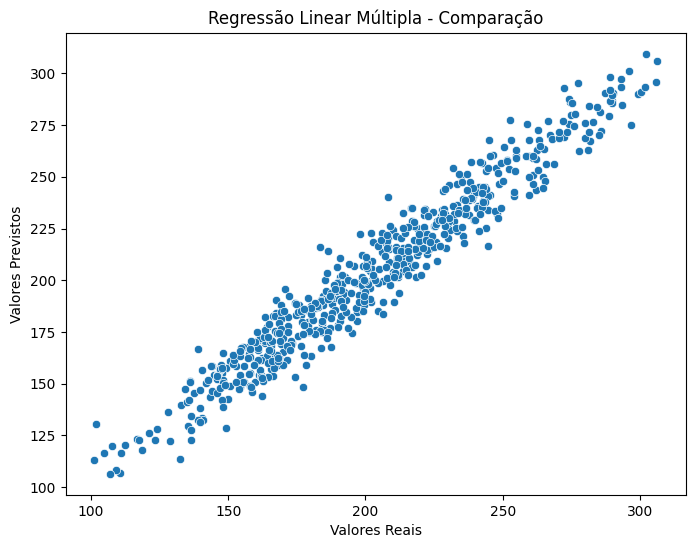

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Valores Reais")
plt.ylabel("Valores Previstos")
plt.title("Regressão Linear Múltipla - Comparação")
plt.show()

In [ ]:
# Regressão Linear Simples (usando a variável mais correlacionada)
X = df[['fertilizante_kg_ha']]
y = df['produtividade_sacos_ha']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
# Avaliação do modelo
print("Coeficiente:", model.coef_)
print("Intercepto:", model.intercept_)
print("R²:", r2_score(y_test, y_pred))
print("Erro Quadrático Médio:", mean_squared_error(y_test, y_pred))

Coeficiente: [0.81574251]
Intercepto: 105.30126257368238
R²: 0.6363830636528478
Erro Quadrático Médio: 663.6362265072772


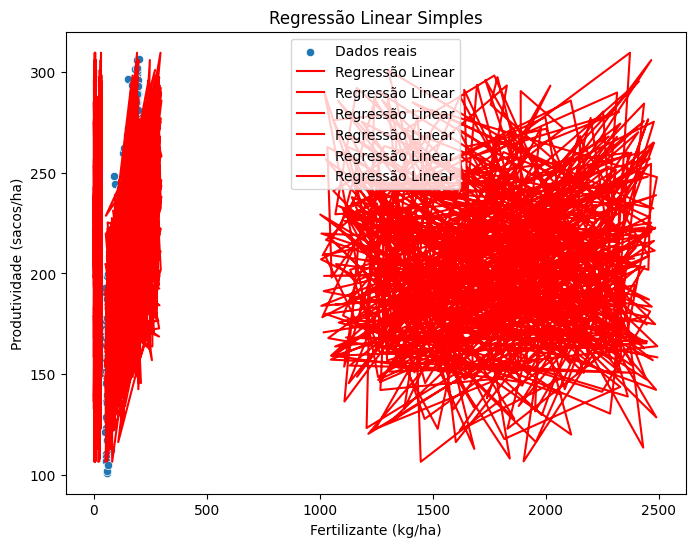

In [ ]:
# Gráfico da regressão simples
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test['fertilizante_kg_ha'], y=y_test, label="Dados reais")
plt.plot(X_test, y_pred, color='red', label="Regressão Linear")
plt.xlabel("Fertilizante (kg/ha)")
plt.ylabel("Produtividade (sacos/ha)")
plt.legend()
plt.title("Regressão Linear Simples")
plt.show()